In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

from src.config import TARGET_COL, PIPELINE_PATH, RANDOM_STATE, TEST_SIZE
from src.preprocessing import build_pipeline
from src.modeling import cross_val_auc, evaluate_on_test, compute_scale_pos_weight

## Load cleaned data

In [2]:
df = pd.read_csv('../data/telco_churn_clean.csv')
print(df.shape)
df.head(2)

(7032, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529


## Train/test split (stratified 80/20)

In [3]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Train: (5625, 20), Test: (1407, 20)
Churn rate train: 0.266 | test: 0.266


## Baseline: always predict majority class

In [4]:
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'Naive majority-class accuracy on test set: {baseline_acc:.3f}')
print('Beat this or your model is useless.')

Naive majority-class accuracy on test set: 0.734
Beat this or your model is useless.


## Model 1: Logistic Regression

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_pipeline = build_pipeline(lr)

lr_cv = cross_val_auc(lr_pipeline, X_train, y_train)
print(f'LR CV AUC: {lr_cv["mean_auc"]:.4f} ± {lr_cv["std_auc"]:.4f}')

lr_pipeline.fit(X_train, y_train)
lr_test = evaluate_on_test(lr_pipeline, X_test, y_test)
print(f'LR Test AUC: {lr_test["auc"]:.4f}')

LR CV AUC: 0.8460 ± 0.0053
LR Test AUC: 0.8361


## Model 2: Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pipeline = build_pipeline(rf)

rf_cv = cross_val_auc(rf_pipeline, X_train, y_train)
print(f'RF CV AUC: {rf_cv["mean_auc"]:.4f} ± {rf_cv["std_auc"]:.4f}')

rf_pipeline.fit(X_train, y_train)
rf_test = evaluate_on_test(rf_pipeline, X_test, y_test)
print(f'RF Test AUC: {rf_test["auc"]:.4f}')

RF CV AUC: 0.8316 ± 0.0061
RF Test AUC: 0.8194


## Model 3: XGBoost (with dynamic scale_pos_weight)

In [7]:
spw = compute_scale_pos_weight(y_train)
print(f'scale_pos_weight (neg/pos ratio): {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    verbosity=0
)
xgb_pipeline = build_pipeline(xgb)

xgb_cv = cross_val_auc(xgb_pipeline, X_train, y_train)
print(f'XGB CV AUC: {xgb_cv["mean_auc"]:.4f} ± {xgb_cv["std_auc"]:.4f}')

xgb_pipeline.fit(X_train, y_train)
xgb_test = evaluate_on_test(xgb_pipeline, X_test, y_test)
print(f'XGB Test AUC: {xgb_test["auc"]:.4f}')

scale_pos_weight (neg/pos ratio): 2.76
XGB CV AUC: 0.8423 ± 0.0040
XGB Test AUC: 0.8275


## Model comparison table

In [8]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'CV AUC': f"{lr_cv['mean_auc']:.4f} ± {lr_cv['std_auc']:.4f}", 'Test AUC': f"{lr_test['auc']:.4f}"},
    {'Model': 'Random Forest',       'CV AUC': f"{rf_cv['mean_auc']:.4f} ± {rf_cv['std_auc']:.4f}", 'Test AUC': f"{rf_test['auc']:.4f}"},
    {'Model': 'XGBoost',             'CV AUC': f"{xgb_cv['mean_auc']:.4f} ± {xgb_cv['std_auc']:.4f}", 'Test AUC': f"{xgb_test['auc']:.4f}"},
])
print(results.to_string(index=False))

              Model          CV AUC Test AUC
Logistic Regression 0.8460 ± 0.0053   0.8361
      Random Forest 0.8316 ± 0.0061   0.8194
            XGBoost 0.8423 ± 0.0040   0.8275


## ROC curves — all three models on one chart

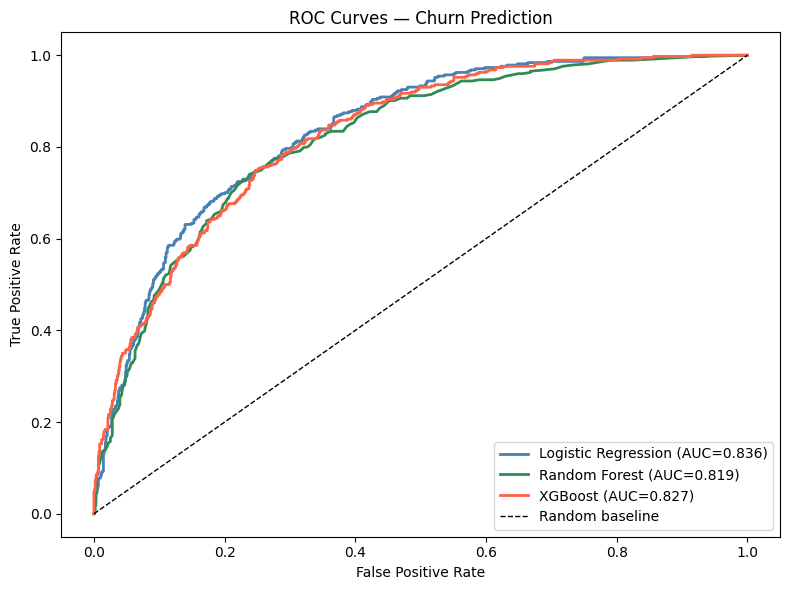

Saved to docs/roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for result, label, color in [
    (lr_test,  f'Logistic Regression (AUC={lr_test["auc"]:.3f})',  'steelblue'),
    (rf_test,  f'Random Forest (AUC={rf_test["auc"]:.3f})',        'seagreen'),
    (xgb_test, f'XGBoost (AUC={xgb_test["auc"]:.3f})',            'tomato'),
]:
    ax.plot(result['fpr'], result['tpr'], label=label, linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Churn Prediction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../docs/roc_curves.png', dpi=150)
plt.show()
print('Saved to docs/roc_curves.png')

## Save best model (XGBoost pipeline)

In [10]:
joblib.dump(xgb_pipeline, PIPELINE_PATH)
print(f'Pipeline saved to {PIPELINE_PATH}')

Pipeline saved to C:\Users\A\Desktop\churn-predictor\data\models\xgb_churn_pipeline.joblib


## Save test set for SHAP notebook (Day 5)

In [11]:
X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
print('Test sets saved.')

Test sets saved.
